# 08 · Benchmark: every family on the same task

**Task:** forecast the next 24 h of Jena temperature from 20 origins over the test period (last 10%). Every model is a `forecast_fn` run through the same `backtest` and the same metrics. This is what `make train` runs; it also logs each model to MLflow.

| family | model | fitted on | notebook |
|---|---|---|---|
| baseline | naive, seasonal naive | – | 02 |
| statistical | Holt-Winters (damped), Theta | last 4 weeks, refit per fold | 03, 05 |
| ML | LightGBM recursive, 48 lags + calendar | train split (once) | 04 |
| deep learning | single-shot LSTM | train split + early stopping on val | 06 |
| foundation | TimesFM 3, $L$=1024 | nothing (zero-shot) | 07 |

In [1]:
%load_ext autoreload
%autoreload 2
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
from tsforecasting.data.data_loader import load_airline, load_jena, temporal_split
from tsforecasting.features.build_features import TARGET

try:
    df = load_jena()
except FileNotFoundError:  # first run: download + clean + features
    from tsforecasting.data import make_dataset
    from tsforecasting.features import build_features
    make_dataset.main(); build_features.main()
    df = load_jena()
y = df[TARGET]
airline = load_airline()
df.shape, airline.shape

((70128, 19), (144,))

In [3]:
from tsforecasting.evaluation import backtest, score
from tsforecasting.models import baselines
from tsforecasting.models import train_model as tm
from tsforecasting.models.foundation import get_device, load_timesfm, timesfm_forecast_fn

train_df, val_df, _ = temporal_split(df)
initial = len(train_df) + len(val_df)
step = (len(df) - initial - tm.HORIZON) // tm.N_FOLDS
device = get_device()

models = {
    "naive": (baselines.naive, None),
    "seasonal_naive": (baselines.seasonal_naive(24), None),
    "ets_holt_winters": (tm.ets_fn, tm.STAT_TRAIN),
    "theta_sktime": (tm.theta_fn, tm.STAT_TRAIN),
    "lightgbm_skforecast": (tm.lightgbm_fn(train_df), None),
    "lstm_pytorch": (tm.lstm_fn(train_df, val_df, device), None),
    "timesfm3_zero_shot": (timesfm_forecast_fn(load_timesfm(device), context_len=1024), None),
}
results = {k: backtest(f, y, initial, tm.HORIZON, step, X=df, max_train=mt, m=24) for k, (f, mt) in models.items()}
board = pd.DataFrame({k: score(r) for k, r in results.items()}).T.sort_values("mase")
board.round(3)

,mae,rmse,smape,mase,pinball,coverage80
lightgbm_skforecast,1.833,2.391,31.688,0.699,NaN,NaN
timesfm3_zero_shot,1.871,2.293,27.914,0.714,0.694,0.812
lstm_pytorch,1.878,2.453,32.008,0.716,NaN,NaN
seasonal_naive,2.329,2.895,36.333,0.889,NaN,NaN
theta_sktime,2.400,3.154,35.633,1.043,NaN,NaN
ets_holt_winters,2.826,3.805,39.927,1.210,NaN,NaN
naive,3.270,4.581,40.466,1.247,NaN,NaN


## 1. Leaderboard

MASE $<1$ beats the in-sample seasonal naive. The dashed line marks 1.

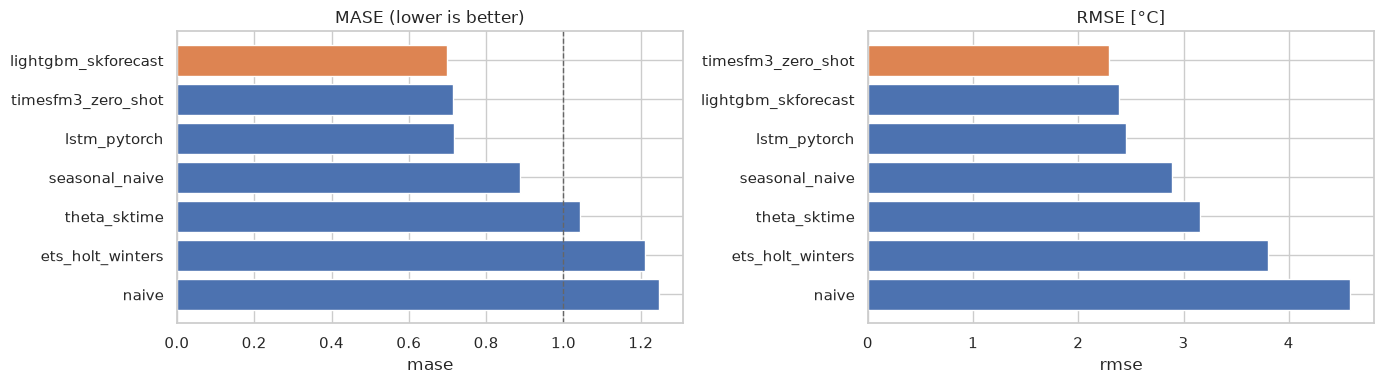

In [4]:
from tsforecasting.visualization.visualize import plot_leaderboard

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_leaderboard(board, "mase", ax=axes[0]).set_title("MASE (lower is better)")
plot_leaderboard(board, "rmse", ax=axes[1]).set_title("RMSE [°C]")
fig.tight_layout()

## 2. Error by horizon step

Where in the 24 h does each model win? Persistence-like models are excellent at $h=1$ and decay fast. Seasonal models are flat.

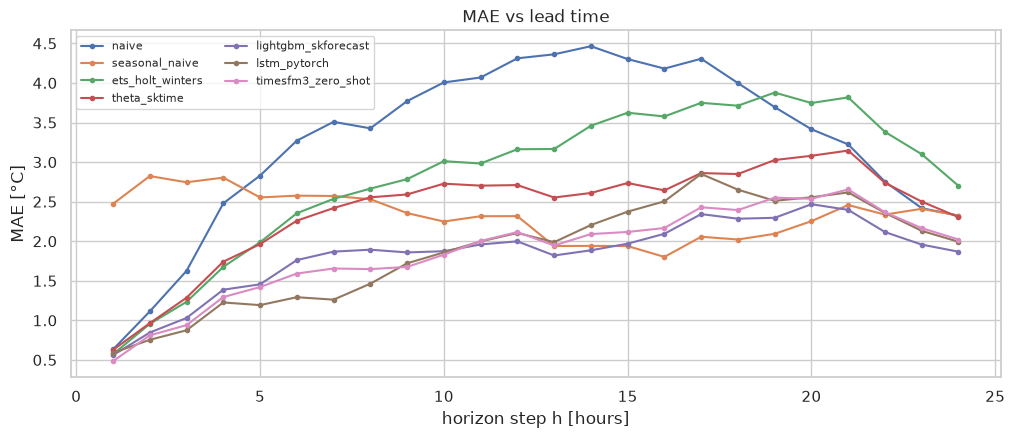

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for k, r in results.items():
    r.assign(ae=(r.y - r["mean"]).abs()).groupby("step").ae.mean().plot(ax=ax, label=k, marker=".")
ax.set(xlabel="horizon step h [hours]", ylabel="MAE [°C]", title="MAE vs lead time"); ax.legend(fontsize=8, ncol=2);

## 3. Error distribution per fold

The mean hides variability. Some weather weeks are simply harder. A model with a lower median *and* tighter spread is more trustworthy.

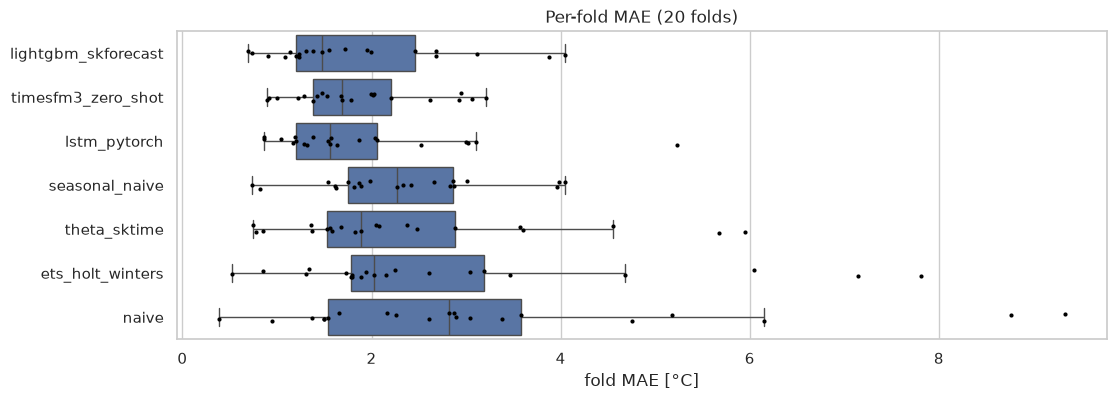

In [6]:
per_fold = pd.concat({k: r.assign(ae=(r.y - r["mean"]).abs()).groupby("fold").ae.mean() for k, r in results.items()},
                     names=["model"]).reset_index()
order = board.index
ax = sns.boxplot(per_fold, x="ae", y="model", order=order, color="C0", fliersize=0)
sns.stripplot(per_fold, x="ae", y="model", order=order, color="black", size=3, ax=ax)
ax.set(xlabel="fold MAE [°C]", ylabel="", title="Per-fold MAE (20 folds)");

## 4. Look at the forecasts

Three representative folds, best models only.

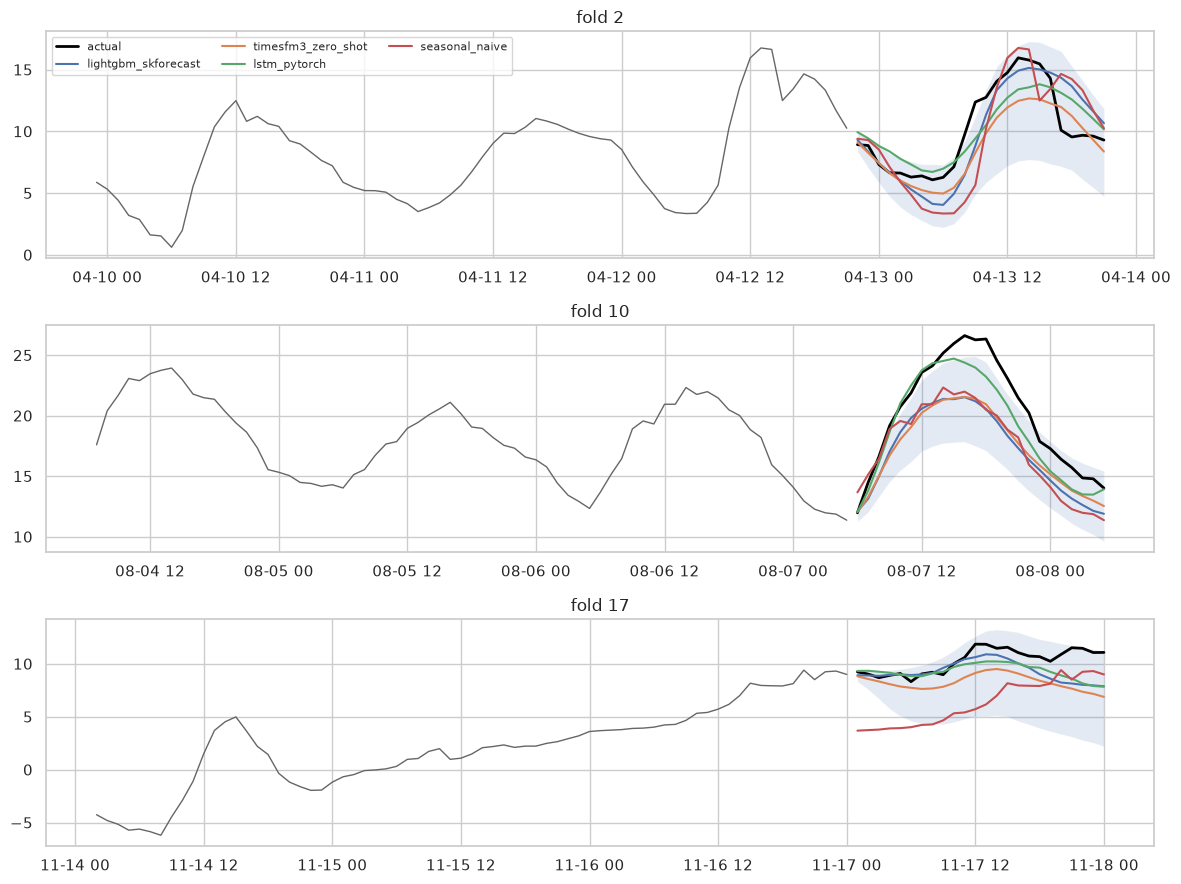

In [7]:
show = list(board.index[:3]) + ["seasonal_naive"]
folds = [2, 10, 17]
fig, axes = plt.subplots(len(folds), 1, figsize=(12, 9), sharex=False)
for ax, k in zip(axes, folds):
    r0 = results[show[0]].query("fold == @k")
    hist = y.loc[: r0.index[0]].iloc[-72:-1]
    ax.plot(hist.index, hist, color="0.4", lw=1)
    ax.plot(r0.index, r0.y, color="black", lw=2, label="actual")
    for name in show:
        r = results[name].query("fold == @k")
        if "q10" in r:
            ax.fill_between(r.index, r.q10, r.q90, alpha=0.15)
        ax.plot(r.index, r["mean"], label=name)
    ax.set_title(f"fold {k}")
axes[0].legend(fontsize=8, ncol=3); fig.tight_layout()

## 5. Experiment tracking with MLflow

`make train` logs one run per model to the `jena-24h-benchmark` experiment. Browse them with `make mlflow-ui`, or query them programmatically:

In [8]:
import mlflow

mlflow.set_tracking_uri(tm.TRACKING_URI)
try:
    runs = mlflow.search_runs(experiment_names=["jena-24h-benchmark"])
    display(runs[["tags.mlflow.runName", "metrics.mase", "metrics.rmse", "metrics.pinball", "start_time"]]
            .sort_values("start_time", ascending=False).head(10))
except Exception as e:
    print("No MLflow runs yet. Run `make train` first.", e)

,tags.mlflow.runName,metrics.mase,metrics.rmse,metrics.pinball,start_time
0,timesfm3_zero_shot,0.713712,2.292881,0.694359,2026-10-03 20:29:33.883000+00:00
1,lstm_pytorch,0.681699,2.318835,NaN,2026-10-03 20:29:08.108000+00:00
2,lightgbm_skforecast,0.699101,2.391432,NaN,2026-10-03 20:29:07.589000+00:00
3,theta_sktime,1.042797,3.153538,NaN,2026-10-03 20:29:07.283000+00:00
4,ets_holt_winters,1.210063,3.804581,NaN,2026-10-03 20:29:06.010000+00:00
5,seasonal_naive,0.888559,2.895238,NaN,2026-10-03 20:28:45.499000+00:00
6,naive,1.246766,4.581312,NaN,2026-10-03 20:28:45.294000+00:00


## Conclusions and where to go next
- On this task, **learned models** (LightGBM, LSTM) and the **zero-shot foundation model** cluster together, clearly ahead of the baselines and of statistical models restricted to one seasonality.
- TimesFM 3 is the only one here giving **calibrated quantiles for free**, with no training data, which makes it an excellent default.

**Ideas for further study**
- Fine-tune TimesFM, or compare it with other foundation models (Chronos-2, Moirai, TimeGPT) through sktime adapters.
- Add Nixtla's `statsforecast` (fast AutoARIMA/MSTL for multiple seasonalities) and `neuralforecast` (N-BEATS, N-HiTS, PatchTST, TFT).
- Probabilistic ML: LightGBM quantile regression, conformalized quantile regression.
- Hierarchical and global models across many series (M5-style).